In [ ]:
#Лабораторная работа №2 Горьков Антон 5130901/30201
# Глава 2. Гармоники

In [13]:
# Подготовка файлов для работы
import os
import urllib.request

def download_file(url, filename):
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)

download_file('https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py', 'thinkdsp.py')


In [76]:
#Упражнение 2.2. Пилообразный сигнал имеет форму волны, которая линейно возрастает от `-1` до `1`,
#затем резко падает до `-1` и повторяется. См. `http://en.wikipedia.org/wiki/Sawtooth_wave`.
#Напишите класс `SawtoothSignal`, который наследуется от `Signal` и реализует метод `evaluate`
#для вычисления пилообразного сигнала. Вычислите спектр пилообразной волны. Как ее
#гармоническая структура соотносится с треугольной и прямоугольной волнами?

In [77]:
import numpy as np
from thinkdsp import Sinusoid
from thinkdsp import decorate

class SawtoothSignal(Sinusoid):
    def evaluate(self, ts):
        # offset переводим из радиан в долю периода.
        cycles = self.freq * ts + self.offset / (2 * np.pi)

        # frac — положение внутри периода, от 0 до 1.
        frac, _ = np.modf(cycles)

        # Преобразуем диапазон [0, 1) в [-1, 1).
        ys = 2 * frac - 1

        # Масштабируем на нужную амплитуду.
        return self.amp * ys

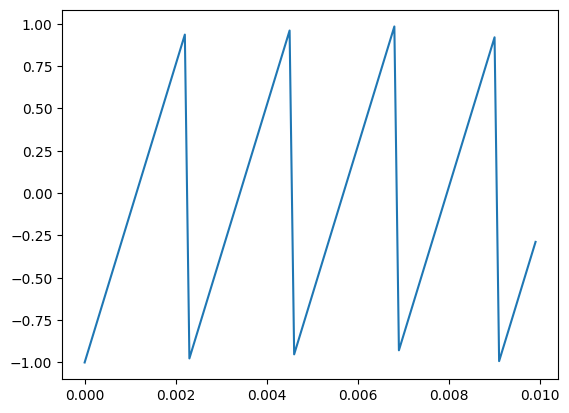

In [78]:
saw = SawtoothSignal(freq=440)
wave = saw.make_wave(duration=0.01, framerate=10000)
wave.plot()

In [79]:
sawtooth = SawtoothSignal().make_wave(duration=0.5, framerate=40000)
sawtooth.make_audio()


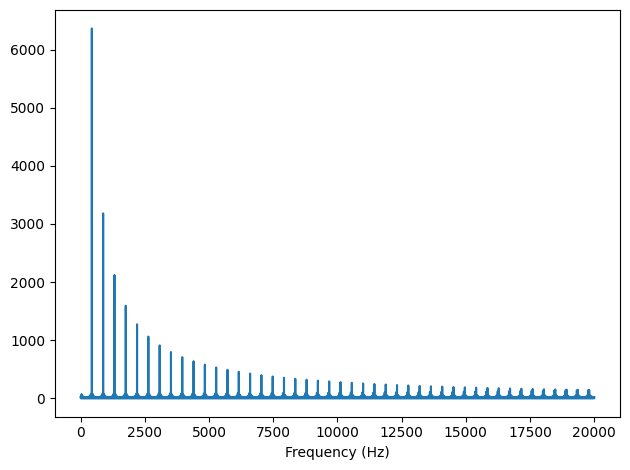

In [80]:
sawtooth.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

In [81]:
# Выводы
#Пилообразная волна содержит как чётные, так и нечётные гармоники.
#Амплитуды её гармоник убывают примерно как 1/f.

#По сравнению с прямоугольной волной:
#- скорость убывания гармоник похожа;
#- но у прямоугольной волны присутствуют только нечётные гармоники.

#По сравнению с треугольной волной:
#- у треугольной волны тоже только нечётные гармоники;
#- амплитуды у неё убывают быстрее, примерно как 1/f^2.

In [82]:
#Упражнение 2.3
#Создайте прямоугольный сигнал 1100 Г ц и вычислите wave с вы-
#борками 10 000 кадров в секунду. Постройте спектр и убедитесь, что
#большинство гармоник «завернуты» из-за биений. Слышны л и по-
#следствия этого при проигрывании?

In [83]:
from thinkdsp import SquareSignal

# Прямоугольный сигнал 1100 Гц
signal = SquareSignal(freq=1100)

# Дискретизация с частотой 10000 отсчётов в секунду
wave = signal.make_wave(duration=0.5, framerate=10000)

In [84]:
wave.make_audio()


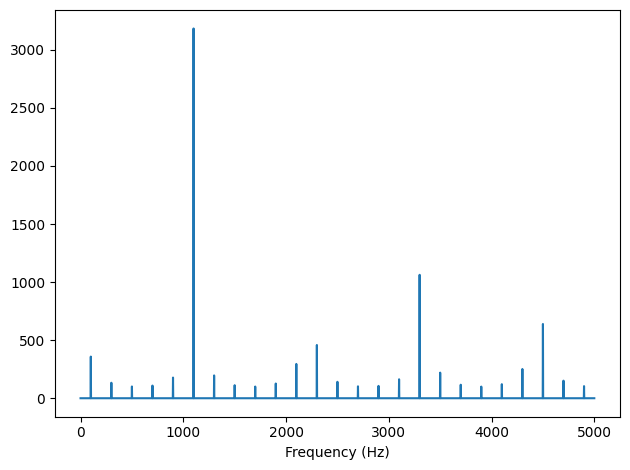

In [85]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

In [86]:
# Выводы

#У прямоугольной волны 1100 Гц многие нечётные гармоники оказываются выше частоты
#Найквиста 5000 Гц и поэтому алиасируются. В результате в спектре появляются
#ложные частоты. При прослушивании это даёт слышимые искажения тембра:
#звук становится более грубым и неестественным.

In [87]:
#Упражнение 2.4
#Возьмите объект Spectrum и распечатайте несколько первых зна-
#чений spectrum.fs. Убедитесь, что о н и начинаются с нуля, то есть
#Spect rum.hs [0] - амплитуда компоненты с частотой 0. Но что это
#значит?
#Проведите такой эксперимент:
#1. Создайте треугольный сигнал с частотой 440 Гц и wave дли-
#тельностью 0,01 секунд. Распечатайте сигнал.
#2. Создайте объект Spectrum и распечатайте Spectrum.hs [0].
#Каковы амплитуда и фаза этого компонента?
#3. Установите Spectrum. hs [0] = 100. Как эта операция повли-
#яет на сигнал? Подсказка: Spectrum дает метод, называемый
#make_wave, вычисляющий wave, соответствующий Spect rum.

Первые значения wave.ys:
[ 0.96388977  0.78967374  0.61545771  0.44124169  0.26702566  0.09280963
 -0.0814064  -0.25562243 -0.42983845 -0.60405448]


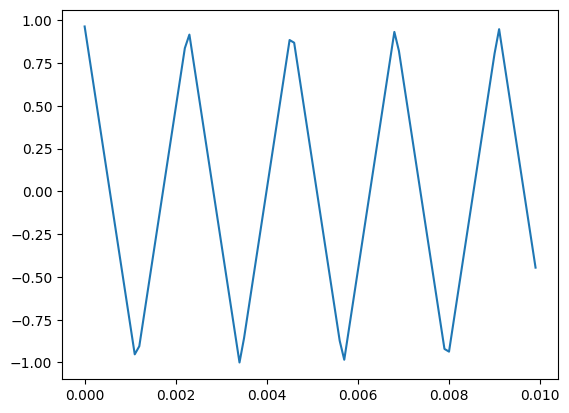

In [88]:
from thinkdsp import TriangleSignal

# 1. Создаём треугольный сигнал 440 Гц и wave длиной 0.01 с
signal = TriangleSignal(freq=440)
wave = signal.make_wave(duration=0.01, framerate=10000)
print('Первые значения wave.ys:')
print(wave.ys[:10])
wave.plot()



In [89]:
# 2. Создаём Spectrum и смотрим первые частоты и компоненту hs[0]

spectrum = wave.make_spectrum()
print('Первые значения spectrum.fs:')
print(spectrum.fs[:10])

print('spectrum.hs[0] =', spectrum.hs[0])
print('Амплитуда компоненты с частотой 0:', abs(spectrum.hs[0]))
print('Фаза компоненты с частотой 0:', np.angle(spectrum.hs[0]))




Первые значения spectrum.fs:
[  0. 100. 200. 300. 400. 500. 600. 700. 800. 900.]
spectrum.hs[0] = (3.375077994860476e-14+0j)
Амплитуда компоненты с частотой 0: 3.375077994860476e-14
Фаза компоненты с частотой 0: 0.0


Первые значения изменённого сигнала:
[1.96388977 1.78967374 1.61545771 1.44124169 1.26702566 1.09280963
 0.9185936  0.74437757 0.57016155 0.39594552]


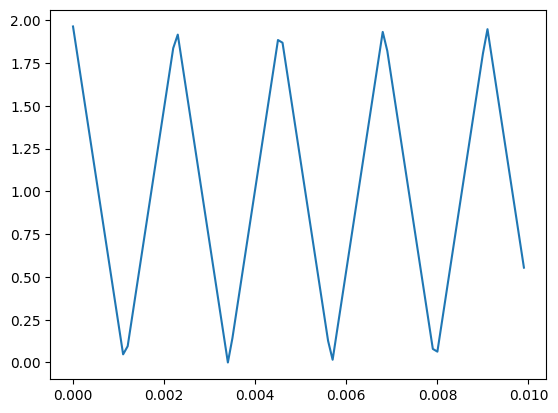

In [90]:
# 3. Меняем нулевую компоненту и восстанавливаем сигнал
spectrum.hs[0] = 100

wave2 = spectrum.make_wave()

print('Первые значения изменённого сигнала:')
print(wave2.ys[:10])

wave2.plot()

In [91]:
# Упражнение 2.5
# Напишите функцию, принимающую Spectrum как параметр и изменяющую его
# делением каждого элемента hs на соответствующую частоту из fs.
# Подсказка: поскольку деление на ноль не определено, надо задать Spectrum.hs[0] = 0.
#
# Проверьте эту функцию, используя прямоугольный, треугольный или пилообразный сигналы:
# 1. Вычислите Spectrum и распечатайте его.
# 2. Измените Spectrum, вновь используя свою функцию, и распечатайте его.
# 3. Используйте Spectrum.make_wave, чтобы сделать wave из измененного Spectrum,
#    и прослушайте его. Как эта операция повлияла на сигнал?

In [92]:
from thinkdsp import SquareSignal
import numpy as np
import matplotlib.pyplot as plt

In [93]:
# Функция, которая делит спектральные коэффициенты на соответствующие частоты
def filter_spectrum(spectrum):
    spectrum.hs[0] = 0
    spectrum.hs[1:] /= spectrum.fs[1:]
    return spectrum

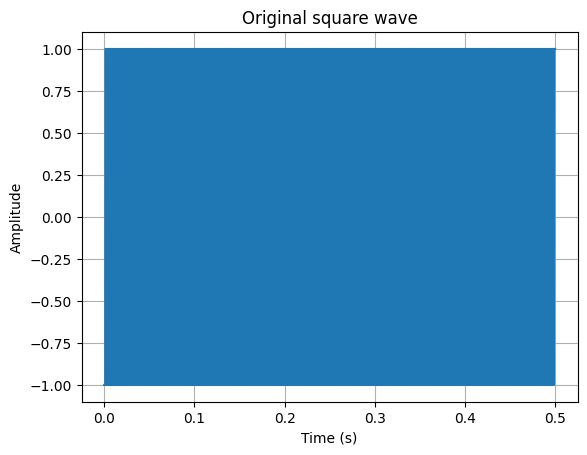

In [94]:
# Возьмём прямоугольный сигнал
signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=0.5, framerate=10000)

# Исходный сигнал
wave.plot()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original square wave")
plt.grid()
plt.show()

wave.make_audio()

In [95]:
# 1. Вычисляем спектр и печатаем его первые значения
spectrum = wave.make_spectrum()

print("Первые 10 значений spectrum.fs:")
print(spectrum.fs[:10])

print("\nПервые 10 значений spectrum.hs:")
print(spectrum.hs[:10])

Первые 10 значений spectrum.fs:
[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]

Первые 10 значений spectrum.hs:
[0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 1.81752977e-14-1.76279216e-14j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]


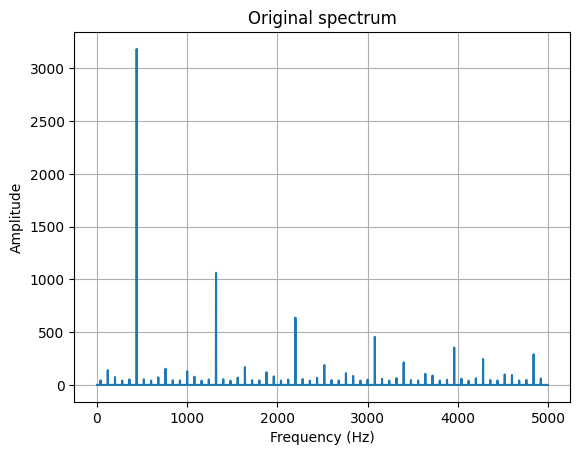

In [96]:
# Для наглядности строим исходный спектр
spectrum.plot(high=5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Original spectrum")
plt.grid()
plt.show()

In [97]:
# 2. Изменяем спектр нашей функцией и печатаем его первые значения
filtered_spectrum = filter_spectrum(spectrum)

print("Первые 10 значений spectrum.fs после обработки:")
print(filtered_spectrum.fs[:10])

print("\nПервые 10 значений spectrum.hs после обработки:")
print(filtered_spectrum.hs[:10])

Первые 10 значений spectrum.fs после обработки:
[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]

Первые 10 значений spectrum.hs после обработки:
[0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 1.81752977e-15-1.76279216e-15j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]


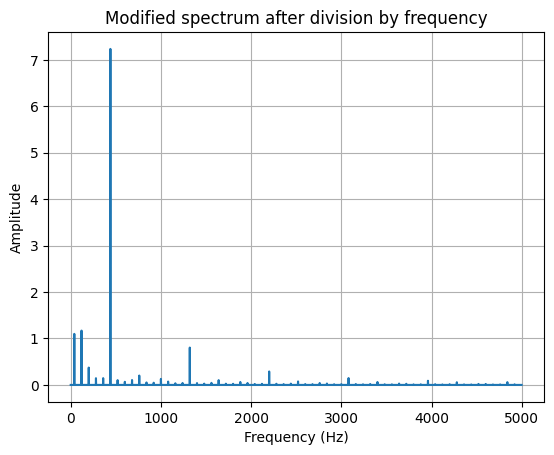

In [98]:
# Строим изменённый спектр
filtered_spectrum.plot(high=5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Modified spectrum after division by frequency")
plt.grid()
plt.show()

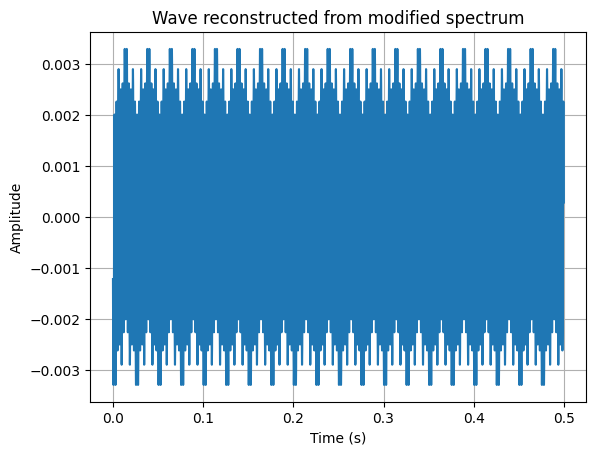

In [99]:
# 3. Восстанавливаем сигнал из изменённого спектра
filtered_wave = filtered_spectrum.make_wave()

# Строим новый сигнал
filtered_wave.plot()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Wave reconstructed from modified spectrum")
plt.grid()
plt.show()

filtered_wave.make_audio()

In [100]:
# Выводы:
# 1. Деление hs на fs уменьшает высокочастотные компоненты сильнее,
#    чем низкочастотные.
# 2. Поэтому спектр после обработки становится "мягче":
#    высокие гармоники ослабляются.
# 3. Во временной области сигнал становится более сглаженным,
#    менее резким.
# 4. Для прямоугольного сигнала после такой операции форма становится
#    ближе к треугольной, потому что именно высокие гармоники отвечают
#    за резкие скачки сигнала.

In [101]:
# Упражнение 2.6
# У треугольных и прямоугольных сигналов есть только нечетные гармоники;
# в пилообразном сигнале есть и четные, и нечетные гармоники.
# Гармоники прямоугольных и пилообразных сигналов уменьшаются
# пропорционально 1/f; гармоники треугольных сигналов — пропорционально 1/f^2.
#
# Можно ли найти сигнал, состоящий из четных и нечетных гармоник,
# спадающих пропорционально 1/f^2?
#
# Подсказка: для этого есть два способа. Можно собрать желаемый
# сигнал из синусоид, а можно взять сигнал со спектром, похожим на
# необходимый, и изменять его параметры.

In [102]:
from thinkdsp import SawtoothSignal
import numpy as np
import matplotlib.pyplot as plt

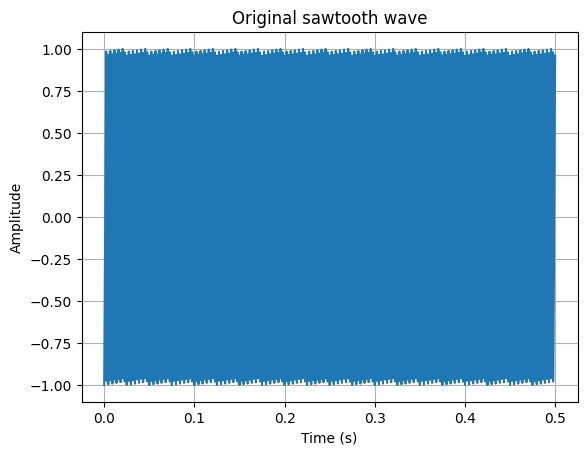

In [103]:
# Возьмём пилообразный сигнал как основу:
# у него есть и чётные, и нечётные гармоники, но они спадают как 1/f.
signal = SawtoothSignal(freq=440)
wave = signal.make_wave(duration=0.5, framerate=20000)

# Посмотрим на исходный сигнал
wave.plot()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original sawtooth wave")
plt.grid()
plt.show()

wave.make_audio()

In [104]:
# 1. Вычисляем исходный спектр
spectrum = wave.make_spectrum()

print("Первые 10 значений spectrum.fs:")
print(spectrum.fs[:10])

print("\nПервые 10 значений spectrum.hs:")
print(spectrum.hs[:10])

Первые 10 значений spectrum.fs:
[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]

Первые 10 значений spectrum.hs:
[-7.10542736e-14+0.00000000e+00j  2.93695987e-13+9.54117582e-14j
  1.48777106e-13+5.75757647e-14j  2.75426821e-13-9.81843865e-14j
  7.77433981e-14+8.60213002e-14j  2.91438090e-13-3.52805782e-15j
  1.91110448e-13-4.26917540e-14j  1.63687586e-13-2.96493451e-14j
  1.27865692e-13+5.82653038e-14j  3.32127701e-13+9.26775850e-14j]


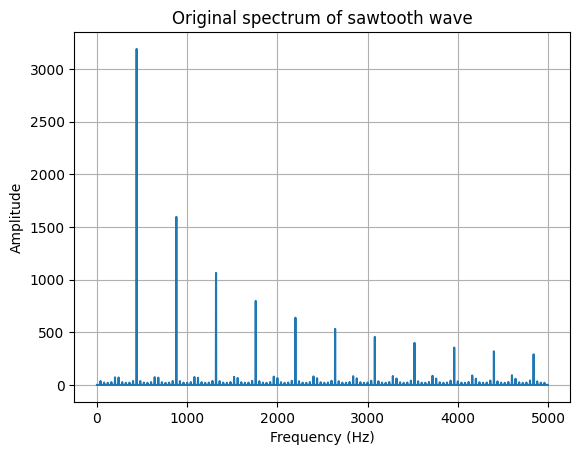

In [105]:
# Строим исходный спектр
spectrum.plot(high=5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Original spectrum of sawtooth wave")
plt.grid()
plt.show()

In [106]:
# 2. Изменяем спектр так, чтобы гармоники спадали как 1/f^2.
# У пилообразного сигнала гармоники уже спадают как 1/f,
# поэтому деление ещё на f даст спад как 1/f^2.

def make_spectrum_fall_as_one_over_f_squared(spectrum):
    spectrum.hs[0] = 0
    spectrum.hs[1:] /= spectrum.fs[1:]
    return spectrum

modified_spectrum = make_spectrum_fall_as_one_over_f_squared(spectrum)

In [107]:
# Печатаем первые значения изменённого спектра
print("Первые 10 значений modified_spectrum.fs:")
print(modified_spectrum.fs[:10])

print("\nПервые 10 значений modified_spectrum.hs:")
print(modified_spectrum.hs[:10])

Первые 10 значений modified_spectrum.fs:
[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]

Первые 10 значений modified_spectrum.hs:
[0.00000000e+00+0.00000000e+00j 1.46847994e-13+4.77058791e-14j
 3.71942765e-14+1.43939412e-14j 4.59044701e-14-1.63640644e-14j
 9.71792476e-15+1.07526625e-14j 2.91438090e-14-3.52805782e-16j
 1.59258707e-14-3.55764617e-15j 1.16919704e-14-2.11781036e-15j
 7.99160577e-15+3.64158149e-15j 1.84515390e-14+5.14875472e-15j]


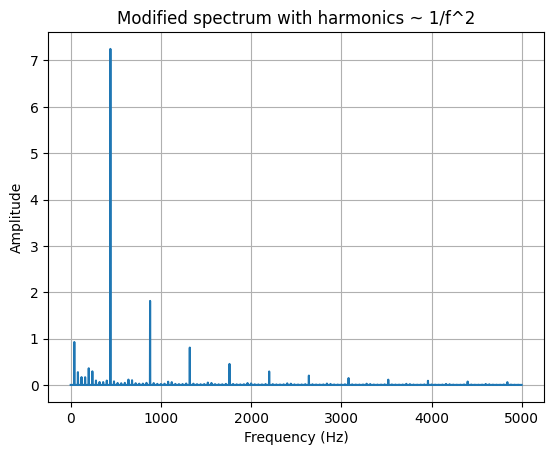

In [108]:
# Строим изменённый спектр
modified_spectrum.plot(high=5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Modified spectrum with harmonics ~ 1/f^2")
plt.grid()
plt.show()

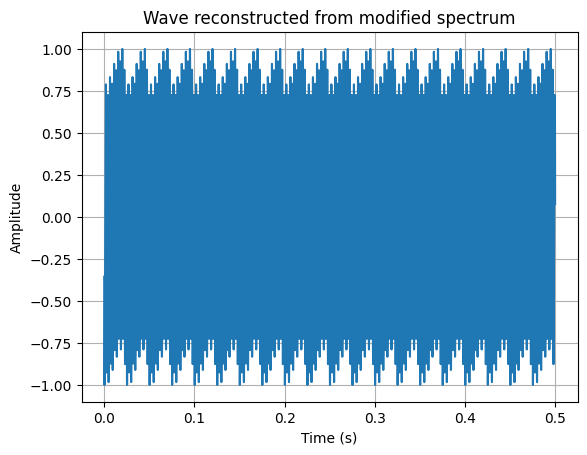

In [109]:
# 3. Восстанавливаем сигнал из изменённого спектра
modified_wave = modified_spectrum.make_wave()
modified_wave.normalize()

# Строим новый сигнал
modified_wave.plot()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Wave reconstructed from modified spectrum")
plt.grid()
plt.show()

modified_wave.make_audio()

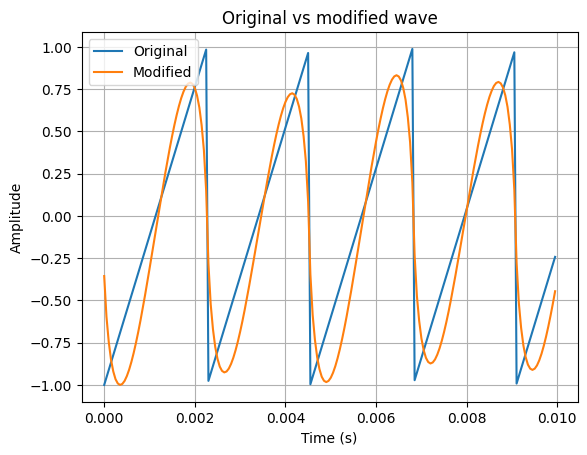

In [110]:
# Сравнение исходного и изменённого сигналов на коротком участке
segment = slice(0, 200)

plt.plot(wave.ts[segment], wave.ys[segment], label="Original")
plt.plot(modified_wave.ts[segment], modified_wave.ys[segment], label="Modified")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original vs modified wave")
plt.grid()
plt.legend()
plt.show()

In [111]:
# Выводы:
# 1. Да, такой сигнал можно получить.
# 2. Удобно взять пилообразный сигнал, потому что он уже содержит
#    и чётные, и нечётные гармоники.
# 3. У пилообразного сигнала гармоники спадают как 1/f.
#    Если дополнительно разделить спектр на f, получится спад как 1/f^2.
# 4. После такой обработки сохраняются и чётные, и нечётные гармоники,
#    но высокочастотные компоненты сильно ослабляются.
# 5. Во временной области сигнал становится более гладким и мягким,
#    чем исходная пилообразная волна.